# <u>From phase space to Krylov space, one shell at a time</u>

# <i>Project notebook</i>

We begin this notebook by importing the necessary packages and modules.

In [1]:
from KrylovQuantumClassical import util
from KrylovQuantumClassical.Hamiltonian import Hamiltonian
from KrylovQuantumClassical.LMG import LMG
from KrylovQuantumClassical.FP import FP
from KrylovQuantumClassical.LanczosQuantum import LanczosQuantum
from KrylovQuantumClassical.classicalFP import classicalFP
from KrylovQuantumClassical.classicalLMG import classicalLMG

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import gc

In [5]:
def one_plot(title, x_label, y_label):

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.set_title(title, fontsize = 14)

    ax.set_xlabel(x_label, fontsize = 12)
    ax.set_ylabel(y_label, fontsize = 12)

    ax.grid(True, linestyle = '-.', which = 'both')
    ax.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

    return fig, ax

In [6]:
def plot_side_by_side(title, x_labels, y_labels):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
    fig.tight_layout(pad = 5.0)

    fig.suptitle(title[0], fontsize=14)
    ax1.set_title(title[1], fontsize = 12)
    ax2.set_title(title[2], fontsize = 12)

    ax1.set_xlabel(x_labels[0], fontsize = 12)
    ax1.set_ylabel(y_labels[0], fontsize = 12)
    ax2.set_xlabel(x_labels[1], fontsize = 12)
    ax2.set_ylabel(y_labels[1], fontsize = 12)

    ax1.grid(True, linestyle = '-.', which = 'both')
    ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
    ax2.grid(True, linestyle = '-.', which = 'both')
    ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

    return fig, (ax1, ax2)

In [7]:
def wrapper_integrability_FP(a: float) -> tuple[float, float]:
    """
    This function is a wrapper for the level_spacing_ratio method of the FP class, which allows us to compute the mean level-spacing ratio for a given value of the parameter a in parallel using joblib.

    Parameters
    ----------
    a: float
        The value of the parameter a for which we want to compute the mean level-spacing ratio of the FP Hamiltonian.

    Returns
    -------
    mean_r: tuple
        A tuple containing the mean level-spacing ratio of the FP Hamiltonian in the (-, +) and (-, -) symmetry blocks, which are the only two blocks that exhibit Poisson to GOE level-spacing statistics transition as a function of the parameter a.

    Example
    -------
    >>> wrapper_integrability_FP(0.0)
    (np.float64(0.5239012374876213), np.float64(0.5239012374876401))
    """
    FP_system = FP(a, 30)
    FP_system.build_intensive()
    mean_r = FP_system.mean_level_spacing_ratio()

    return mean_r

## <span style="color:orange">1.  The LMG and FP models</span>

<span><i>In this section, $\textcolor{red}{bla bla}$.</i></span>

The low- and high-energy spectrum of the LMG can be described by bosonic excitations and approximate formulas can be obtained in both regimes where $h<J$ and $h>J$. Let us illustrate these.

In [8]:
LMG_system = LMG(1, 1, 40)
H_LMG = LMG_system.build_intensive()

Sx, Sy, Sz = util.spin_operators(LMG_system.S)
identity_op = np.eye(2 * LMG_system.S + 1)
sx, sy, sz = Sx / LMG_system.S, Sy / LMG_system.S, Sz / LMG_system.S

time_grid = np.linspace(0, 1e3, num = int(1e4))
test_1 = LMG_system.autocorrelation(sz, time_grid) 
test_2 = LMG_system.autocorrelation(sy, time_grid) 
test_3 = LMG_system.autocorrelation(sz + sy, time_grid)
test_4 = LMG_system.autocorrelation(sz - sy, time_grid)

KeyboardInterrupt: 

In [ ]:
import scipy.linalg as la

In [ ]:
np.trace(sz @ la.expm(-1j * H_LMG * 1.4524) @ sy @ la.expm(1j * H_LMG * 1.4524)) 

np.complex128(-1.0046132216747021+1.5201693873763075e-16j)

In [ ]:
np.trace(sy @ la.expm(1j * H_LMG * 1.4524) @ sz @ la.expm(-1j * H_LMG * 1.4524))

np.complex128(-1.0046132216747021+5.192311966668861e-17j)

In [ ]:
print(test_1[3 * int(1e3)])
print(test_2[3 * int(1e3)])
print(test_3[3 * int(1e3)])
print(test_4[3 * int(1e3)])
print((test_1[3 * int(1e3)] + test_2[3 * int(1e3)]) / 2)

(-0.02873130113801715-1.0451173534280023e-17j)
(-0.2113216365706087+2.655626061989186e-18j)
(-0.12002646885431298-8.22387425648264e-18j)
(-0.12002646885431298-8.22387425648264e-18j)
(-0.12002646885431292-3.897773736145419e-18j)


In [ ]:
FP_system = FP(0.5, 4)
H_FP = FP_system.build_intensive()

Lx, Ly, Lz = util.spin_operators(FP_system.L)
identity_op = np.eye(2 * FP_system.L + 1)
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L

time_grid = np.linspace(0, 1e3, num = int(1e4))
test_1 = FP_system.autocorrelation(np.kron(ly, ly), time_grid)
test_2 = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
test_3 = FP_system.autocorrelation(np.kron(ly, ly) + np.kron(lz, lx), time_grid)
test_4 = FP_system.autocorrelation(np.kron(ly, ly) - np.kron(lz, lx), time_grid)

In [ ]:
1 / 9 ** 4

0.00015241579027587258

In [ ]:
print(test_1[4 * int(1e3)])
print(test_2[4 * int(1e3)])
print(test_3[4 * int(1e3)])
print(test_4[4 * int(1e3)])
print((test_1[4 * int(1e3)] + test_2[4 * int(1e3)]) / 2)

(0.4209575706583717-2.741291418827547e-18j)
(-0.03235411501730306+2.741291418827547e-18j)
(0.19430172782053384-2.1245008495913488e-17j)
(0.1943017278205342+1.3021134239430848e-17j)
(0.19430172782053431+0j)


In [ ]:
print(test_1[4 * int(1e3)])
print(test_2[4 * int(1e3)])
print(test_3[4 * int(1e3)])
print(test_4[4 * int(1e3)])
print((test_1[4 * int(1e3)] + test_2[4 * int(1e3)]) / 2)

(0.4209575706583717-2.741291418827547e-18j)
(-0.032354115017303564+4.5231308410654523e-17j)
(0.19430172782053384-2.1245008495913488e-17j)
(0.1943017278205342+1.3021134239430848e-17j)
(0.19430172782053406+2.1245008495913488e-17j)


In [ ]:
FP_system = FP(0.5, 4)
Lx, Ly, Lz = util.spin_operators(FP_system.L) 
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L
identity_op = np.eye(2 * FP_system.L + 1)

time_grid = np.logspace(-4, 16, num = int(1e5)) * FP_system.spectral_width() / FP_system.L

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lz), time_grid)
    result_all.append(result)

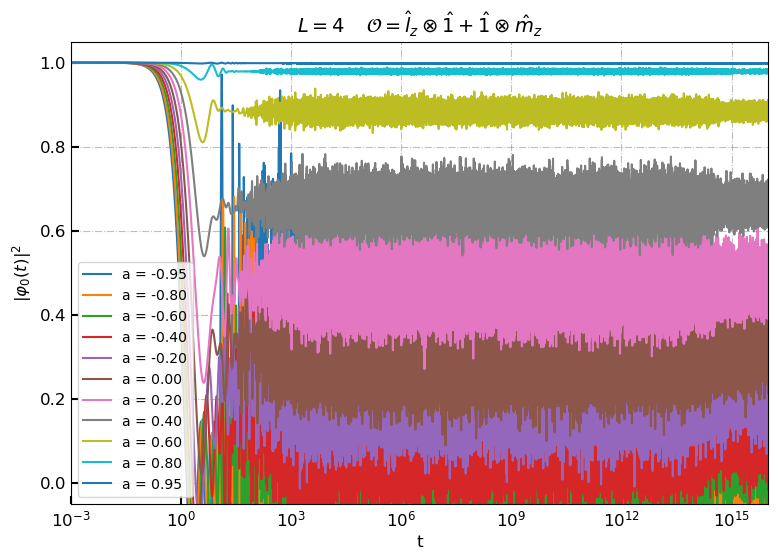

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_z\otimes \hat{1}+\hat{1}\otimes\hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")

ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')

plt.legend()
plt.savefig("../FP_autocorrelation_1.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lx, lx), time_grid)
    result_all.append(result)

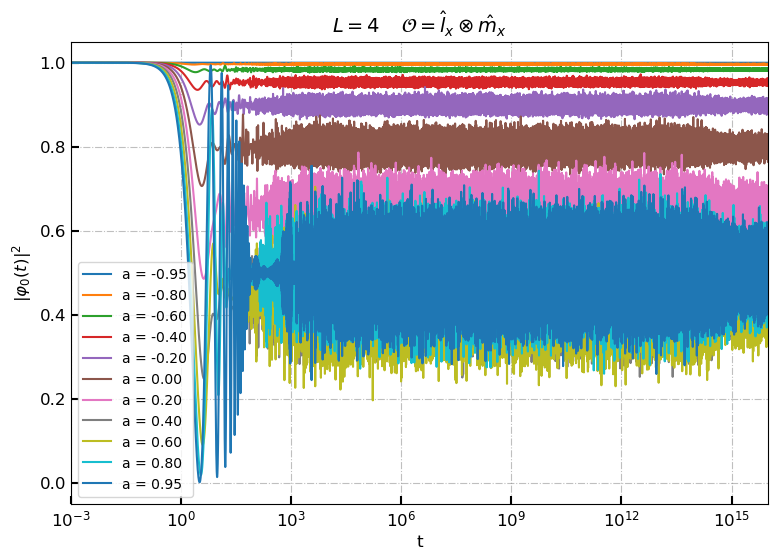

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_x\otimes \hat{m}_x$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_2.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
    result_all.append(result)

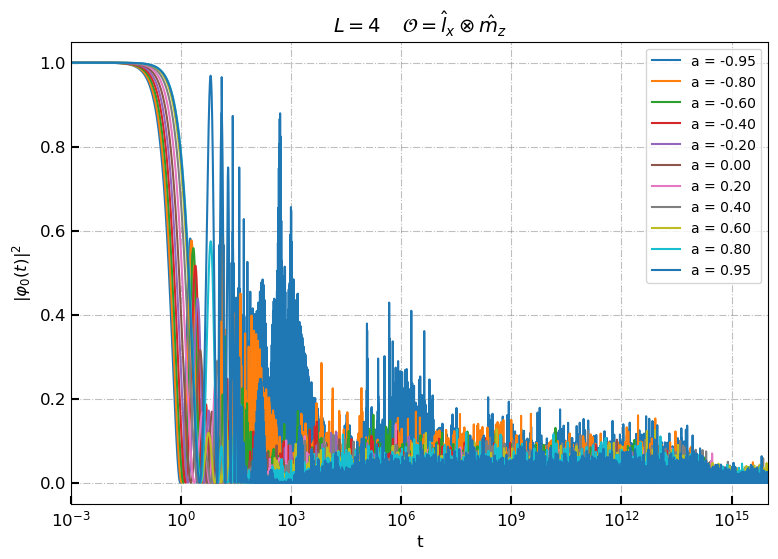

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_x\otimes \hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, np.abs(result.real) ** 2, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_3.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(ly, identity_op) + np.kron(identity_op, ly), time_grid)
    result_all.append(result)

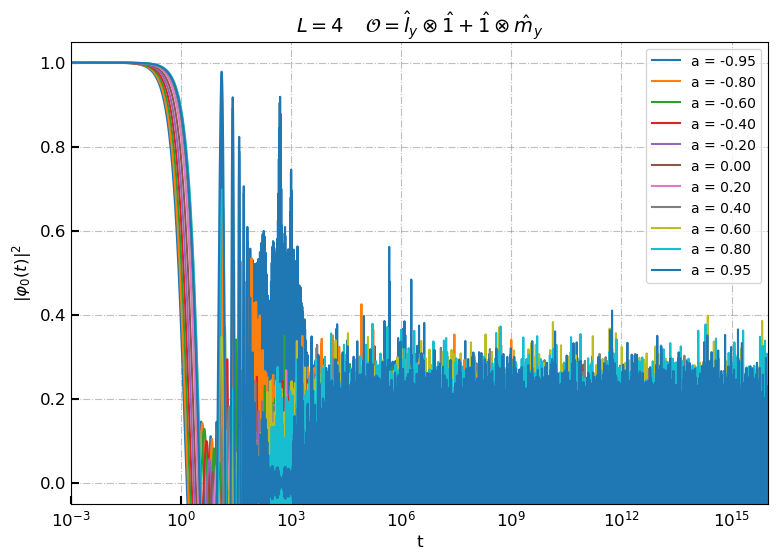

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_y\otimes \hat{1}+\hat{1}\otimes\hat{m}_y$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_4.pdf", dpi = 300)
plt.show()

In [ ]:
FP_system = FP(0., 5)

Lx, Ly, Lz = util.spin_operators(FP_system.L) 
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L
identity_op = np.eye(2 * FP_system.L + 1)

time_grid = np.logspace(-3, 17, num = int(1e5)) * FP_system.spectral_width() / (FP_system.L ** 2)
H_FP = FP_system.build_intensive()
result_1 = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lz), time_grid)
result_2 = FP_system.autocorrelation(np.kron(lx, lx), time_grid)
result_3 = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
result_4 = FP_system.autocorrelation(np.kron(ly, identity_op) + np.kron(identity_op, ly), time_grid)

result_1 = np.abs(result_1) ** 2
result_2 = np.abs(result_2) ** 2
result_3 = np.abs(result_3) ** 2
result_4 = np.abs(result_4) ** 2

In [ ]:
np.savetxt("../Project 2/Data/autocorrelation_FP_lambda_" + str(FP_system.a) + ".txt", [result_1, result_2, result_3, result_4])
np.savetxt("../Project 2/Data/autocorrelation_FP_lambda_" + str(FP_system.a) + "_time_grid.txt", time_grid)

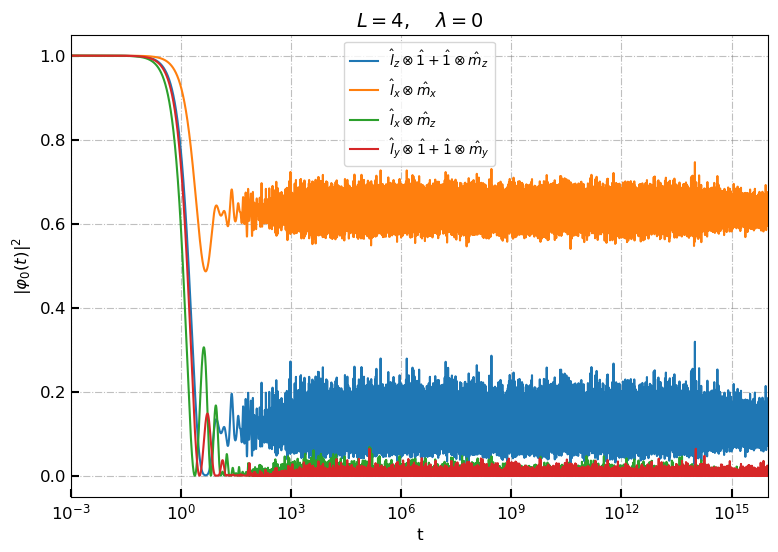

In [ ]:
_, ax = one_plot(r"$L=4,\,\quad  \lambda=0$", "t", r"$|\varphi_0(t)|^2$")
ax.plot(time_grid, result_1, label = r"$\hat{l}_z\otimes \hat{1}+\hat{1}\otimes\hat{m}_z$")
ax.plot(time_grid, result_2, label = r"$\hat{l}_x\otimes \hat{m}_x$")
ax.plot(time_grid, result_3, label = r"$\hat{l}_x\otimes \hat{m}_z$")
ax.plot(time_grid, result_4, label = r"$\hat{l}_y\otimes \hat{1}+\hat{1}\otimes\hat{m}_y$")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_all_2.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-1, -0.99, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.99, 1])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lz, identity_op) - np.kron(identity_op, lz), time_grid)
    result_all.append(result)

In [ ]:
D = 2 * FP_system.L + 1
A = np.kron(Lz, np.eye(D)) + np.kron(np.eye(D), Lz)
B = np.kron(Lz, np.eye(D)) - np.kron(np.eye(D), Lz)
np.allclose(A @ B - B @ A, np.zeros_like(A))

True

In [ ]:
np.trace(np.kron(lx @ lx, identity_op))

np.complex128(33.75+0j)

In [ ]:
FP_system = FP(-0.5, 4)
H_FP = FP_system.build_intensive()
test_1 = FP_system.autocorrelation(np.kron(lz, identity_op), time_grid) 
test_2 = FP_system.autocorrelation(np.kron(identity_op, lx), time_grid) 
test_3 = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lx), time_grid)
test_4 = FP_system.autocorrelation(np.kron(lz, identity_op) - np.kron(identity_op, lx), time_grid)
test_5 = FP_system.autocorrelation(np.kron(lx, lx), time_grid)

In [ ]:
print(test_1[4 * int(1e4)])
print(test_2[4 * int(1e4)])
print(test_3[4 * int(1e4)])
print(test_4[4 * int(1e4)])

(0.0401397669005822-1.02798428206033e-17j)
(0.5858349162435375+6.6818978333921455e-18j)
(0.31298734157198044-1.3706457094137734e-18j)
(0.31298734157213937-5.825244265008537e-18j)


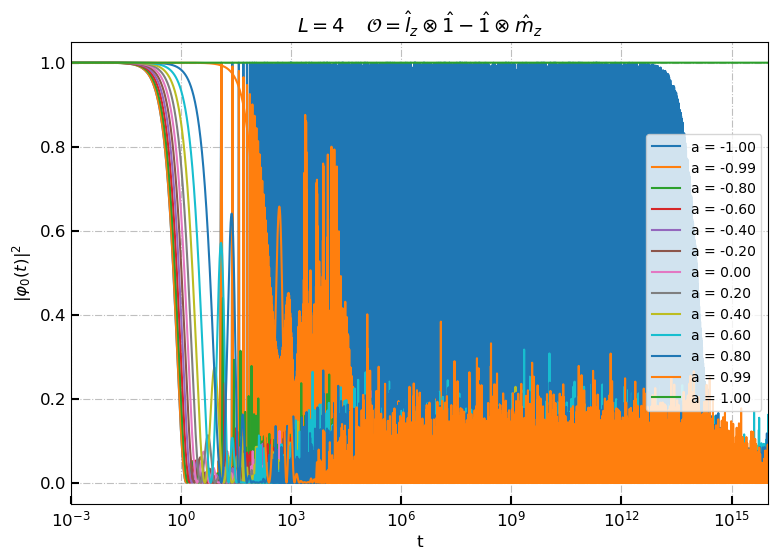

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_z\otimes \hat{1}-\hat{1}\otimes \hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_5.pdf", dpi = 300)
plt.show()

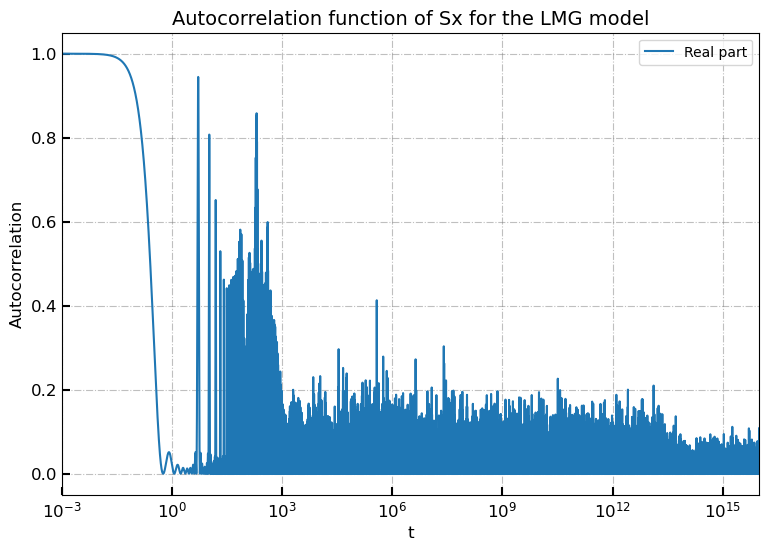

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result_all[0].real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

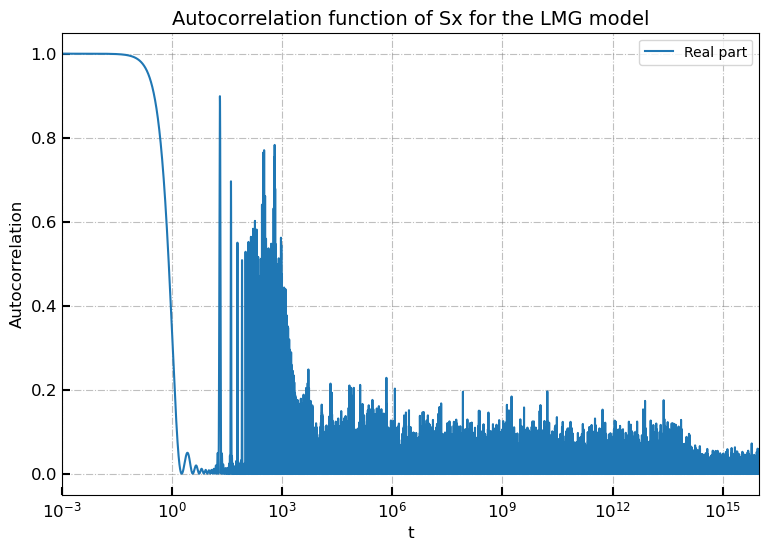

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, test.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

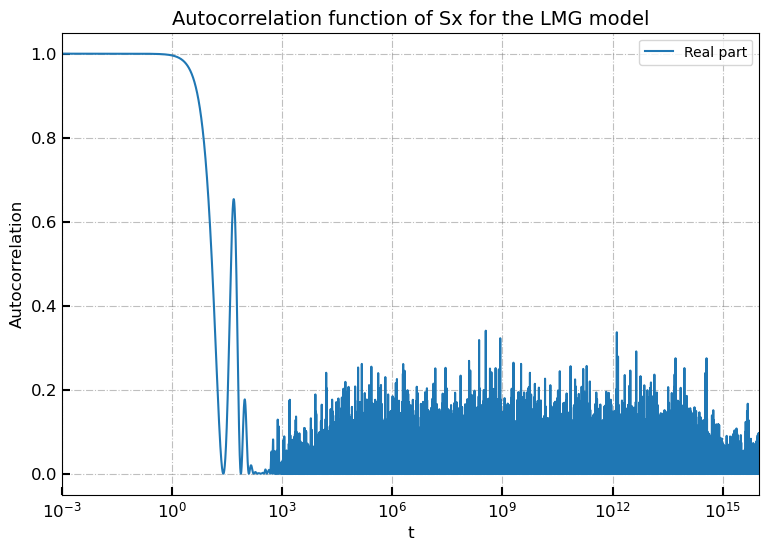

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

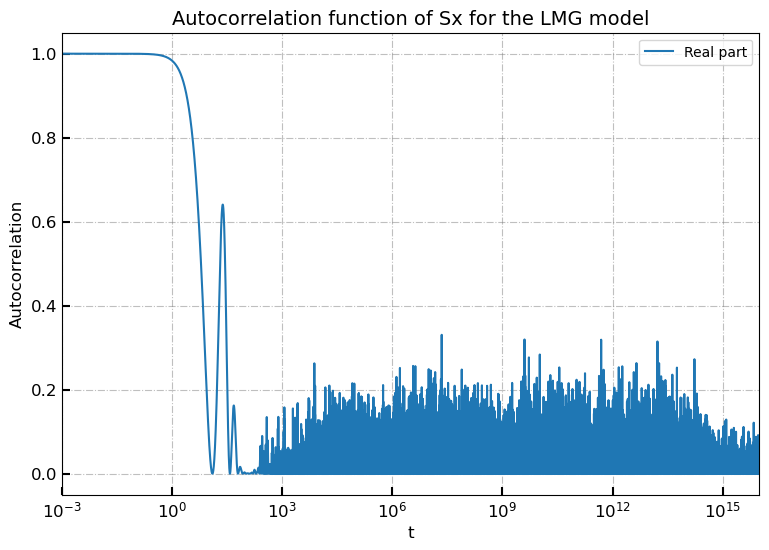

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

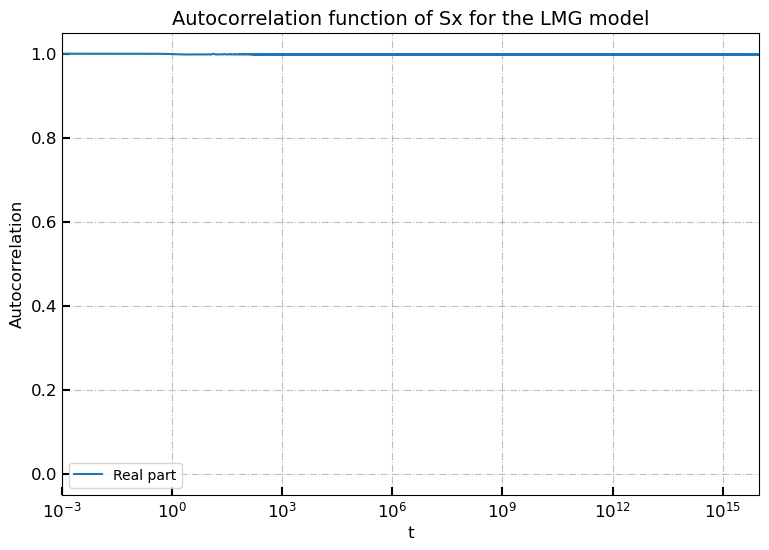

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 500)
H_LMG_1 = LMG_system_1.build_intensive()

LMG_system_2 = LMG(2.0, 1.0, 500)
H_LMG_2 = LMG_system_2.build_intensive()

E_LMG_spectrum_1, _ = np.linalg.eigh(H_LMG_1)
E_LMG_spectrum_2, _ = np.linalg.eigh(H_LMG_2)

In [ ]:
E_list = np.arange(1, len(E_LMG_spectrum_1) + 1)

fig, (ax1, ax2) = plot_side_by_side(
    title = ['Low- and high-energy spectra of the LMG model', r'$h<J$', r'$h>J$'],
    x_labels = [r'$k$', r'$k$'],
    y_labels = [r'$E_k/J$', r'$E_k/J$'])

ax1.plot(E_list, E_LMG_spectrum_1, color = 'cornflowerblue')
ax1.plot(E_list[:300], np.sqrt(LMG_system_1.J ** 2 - LMG_system_1.h ** 2) * E_list[:300] / (2 * LMG_system_1.S) + E_LMG_spectrum_1[0] , color = 'darkgrey', label = 'Low-energy spectrum')
ax1.plot(E_list[-300:], np.sqrt(LMG_system_1.h * (LMG_system_1.h + LMG_system_1.J)) * E_list[-300:] / (LMG_system_1.S) - np.sqrt(LMG_system_1.h * (LMG_system_1.h + LMG_system_1.J)) * E_list[-1] / (LMG_system_1.S) + E_LMG_spectrum_1[-1], color = 'black', label = 'High-energy spectrum')

ax2.plot(E_list, E_LMG_spectrum_2, color = 'lightcoral')
ax2.plot(E_list[:300], np.sqrt(LMG_system_2.h * (LMG_system_2.h - LMG_system_2.J)) * E_list[:300] / (LMG_system_2.S) + E_LMG_spectrum_2[0] , color = 'darkgrey', label = 'Low-energy spectrum')
ax2.plot(E_list[-300:], np.sqrt(LMG_system_2.h * (LMG_system_2.h + LMG_system_2.J)) * E_list[-300:] / (LMG_system_2.S) - np.sqrt(LMG_system_2.h * (LMG_system_2.h + LMG_system_2.J)) * E_list[-1] / (LMG_system_2.S) + E_LMG_spectrum_2[-1], color = 'black', label = 'High-energy spectrum')

ax1.legend(fontsize = 10)

plt.show()

We now compute the densiy of states (DOS) for the LMG model in both regimes $h<J$ and $h>J$.

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 1000)
LMG_system_2 = LMG(2.0, 1.0, 1000)

H_LMG_1  =  LMG_system_1.build_intensive()
H_LMG_2  =  LMG_system_2.build_intensive()

E_LMG_1, E_grid_1, rho_1 = LMG_system_1.compute_DOS()
E_LMG_2, E_grid_2, rho_2 = LMG_system_2.compute_DOS()

hist_1, edges_1 = np.histogram(E_LMG_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_LMG_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_2, rho_2, color='lightcoral')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

The DOS can also be computed in the two symmetry blocks of the LMG Hamiltonian, which are obtained by block-diagonalizing the Hamiltonian using the parity operator. The resulting DOSs are essentially the same as the DOS computed in the full Hilbert space.

In [ ]:
E_LMG_blocks_1, E_grid_blocks_1, rho_blocks_1 = LMG_system_1.compute_DOS(symmetry_blocks = True)
E_LMG_blocks_2, E_grid_blocks_2, rho_blocks_2 = LMG_system_2.compute_DOS(symmetry_blocks = True)

hist_list = []
centers_list = []

for E_LMG_blocks in [E_LMG_blocks_1, E_LMG_blocks_2]:
    hist_blocks = []
    centers_blocks = []
    for E_block in E_LMG_blocks:
        hist_block, edges_block = np.histogram(np.real(E_block), bins = 75, density = True)
        centers_block = 0.5 * (edges_block[:-1] + edges_block[1:])
        hist_blocks.append(hist_block)
        centers_blocks.append(centers_block)
    hist_list.append(hist_blocks)
    centers_list.append(centers_blocks)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model: $(+)$ symmetry sector', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_blocks_1[0], rho_blocks_1[0], color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_blocks_2[0], rho_blocks_2[0], color='lightcoral')

ax1.bar(centers_list[0][0], hist_list[0][0], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][0], hist_list[1][0], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model: $(-)$ symmetry sector', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_blocks_1[1], rho_blocks_1[1], color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_blocks_2[1], rho_blocks_2[1], color='lightcoral')

ax1.bar(centers_list[0][1], hist_list[0][1], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][1], hist_list[1][1], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
FP_system_1 = FP(0.0, 20)
FP_system_2 = FP(0.9, 20)

H_FP_1  =  FP_system_1.build_intensive()
H_FP_2  =  FP_system_2.build_intensive()

E_FP_1, E_grid_1, rho_1 = FP_system_1.compute_DOS()
E_FP_2, E_grid_2, rho_2 = FP_system_2.compute_DOS()

hist_1, edges_1 = np.histogram(E_FP_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_FP_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_2, rho_2, color='lightcoral')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5) 

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
E_FP_blocks_1, E_grid_blocks_1, rho_blocks_1 = FP_system_1.compute_DOS(symmetry_blocks = True)
E_FP_blocks_2, E_grid_blocks_2, rho_blocks_2 = FP_system_2.compute_DOS(symmetry_blocks = True)

hist_list = []
centers_list = []

for E_LMG_blocks in [E_FP_blocks_1[2 :], E_FP_blocks_2[2 :]]:
    hist_blocks = []
    centers_blocks = []
    for E_block in E_LMG_blocks:
        hist_block, edges_block = np.histogram(np.real(E_block), bins = 75, density = True)
        centers_block = 0.5 * (edges_block[:-1] + edges_block[1:])
        hist_blocks.append(hist_block)
        centers_blocks.append(centers_block)
    hist_list.append(hist_blocks)
    centers_list.append(centers_blocks)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model: $(-, +)$ symmetry sector', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])  

ax1.plot(E_grid_blocks_1[0], rho_blocks_1[0], color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_blocks_2[0], rho_blocks_2[0], color='lightcoral')
ax1.bar(centers_list[0][0], hist_list[0][0], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][0], hist_list[1][0], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model: $(-, -)$ symmetry sector', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])  

ax1.plot(E_grid_blocks_1[1], rho_blocks_1[1], color = 'cornflowerblue', label = 'Smoothed DOS')
ax2.plot(E_grid_blocks_2[1], rho_blocks_2[1], color='lightcoral')
ax1.bar(centers_list[0][1], hist_list[0][1], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][1], hist_list[1][1], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

Since the ground state is degenerate in the regime $h<J$, it is more convenient to illustrate the quantum phase transition (QPT) by plotting the magnetization of the operator $\hat{s}_z^2$ in the ground state as a function of $h$. The magnetization is defined as $m = \langle \psi_0 | \hat{s}_z^2 | \psi_0 \rangle$, where $|\psi_0\rangle$ is the ground state of the system. In the thermodynamic limit, we expect a sharp transition in the magnetization at the critical point $h=J$. For finite systems, this transition will be smoothed out, but we should still see a significant change in the magnetization around the critical point. The excited state quantum phase transition (ESQPT) can be illustrated by plotting the magnetization of the operator $\hat{s}_z^2$ in the first excited state as a function of $h$.

In [ ]:
h_list = np.linspace(0.0, 2, 101)
m_list_QPT_LMG = np.zeros(len(h_list), dtype = complex)
m_list_ESQPT_LMG = np.zeros(len(h_list), dtype = complex)

S = 200
Sx, Sy, Sz = util.spin_operators(S)

for i, h in enumerate(h_list):
    LMG_system = LMG(h, 1.0, S)
    LMG_system.build_intensive()
    m_list_QPT_LMG[i] = LMG_system.magnetization(operator = Sz @ Sz / S ** 2)
    m_list_ESQPT_LMG[i] = LMG_system.magnetization(level = 2, operator = Sz @ Sz / S ** 2)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model', 'QPT', 'ESQPT'],
    x_labels = [r'$h$', r'$h$'],
    y_labels = [r'$m(\hat{s}_z^2)$', r'$m(\hat{s}_z^2)$'])

ax1.plot(h_list, np.real(m_list_QPT_LMG), color = 'cornflowerblue', label = 'Ground state')
ax2.plot(h_list, np.real(m_list_ESQPT_LMG), color='lightcoral', label = 'Second excited state')

ax1.axvline(x = 1, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 1, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 10)
ax2.legend(fontsize = 10)

plt.show()

The idea is similar for the FP model. Here, the order parameter for the ground-state QPT is $\langle \psi_0 | \hat{s}_x \otimes \hat{s}_x | \psi_0 \rangle$. The QPT and ESQPT occur at $\lambda = 3/5$ in the thermodynamic limit.

In [ ]:
a_list = np.linspace(- 1, 1, 101)
m_list_QPT_FP = np.zeros(len(a_list), dtype = complex)
m_list_ESQPT_FP = np.zeros(len(a_list), dtype = complex)

for i, a in enumerate(a_list):
    FP_system = FP(a, 15)
    FP_system.build_intensive()
    m_list_QPT_FP[i] = FP_system.magnetization()
    m_list_ESQPT_FP[i] = FP_system.magnetization(level = 2)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model', 'QPT', 'ESQPT'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$m(\hat{s}_x\otimes \hat{s}_x)$', r'$m(\hat{s}_x\otimes \hat{s}_x)$'])

ax1.plot(a_list, np.real(m_list_QPT_FP), color = 'cornflowerblue', label = 'Ground state')
ax2.plot(a_list, np.real(m_list_ESQPT_FP), color='lightcoral', label = 'ESQPT magnetization (level 2)')

ax1.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 10)
ax2.legend(fontsize = 10)

plt.show()

Exploring quasi-degeneracies in the LMG model.

In [ ]:
h_list = np.linspace(0.0, 2, 101)

E_spectrum_minus_list = []
E_spectrum_plus_list = []

for h in h_list:
    LMG_system = LMG(h, 1.0, 10)
    LMG_system.build_intensive()
    E_spectrum_blocks = LMG_system.symmetry_blocks(spectrum = True)
    E_spectrum_minus_list.append(E_spectrum_blocks[2])
    E_spectrum_plus_list.append(E_spectrum_blocks[3])

E_spectrum_minus_array = np.array(E_spectrum_minus_list)
E_spectrum_plus_array = np.array(E_spectrum_plus_list)

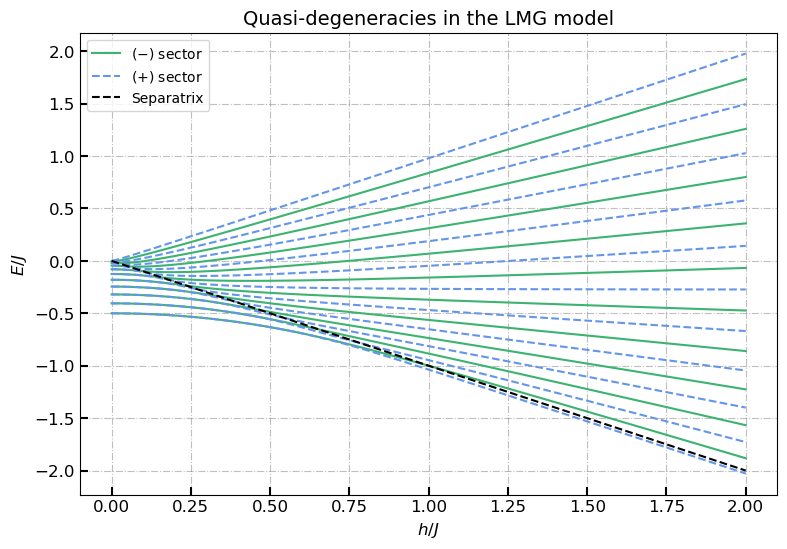

In [ ]:
fig, ax = one_plot(
    title = 'Quasi-degeneracies in the LMG model',
    x_label = r'$h/J$',
    y_label = r'$E/J$')

for i, x in enumerate(E_spectrum_minus_array.T):
    ax.plot(h_list, x, color = 'mediumseagreen', label = '$(-)$ sector' if i == 0 else "")

for i, x in enumerate(E_spectrum_plus_array.T):
    ax.plot(h_list, x, color = 'cornflowerblue', linestyle = '--', label = '$(+)$ sector' if i == 0 else "")

ax.plot(h_list, - h_list, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrix')

ax.legend(fontsize = 10)

plt.show()

Exploring quasi-degeneracies in the FP model.

In [ ]:
a_list = np.linspace(- 1, 1, 101)

E_spectrum_blocks_p_p = []
E_spectrum_blocks_p_m = []
E_spectrum_blocks_m_p = []
E_spectrum_blocks_m_m = []

for a in a_list:
    FP_system = FP(a, 3)
    FP_system.build_intensive()
    E_spectrum_blocks = FP_system.symmetry_blocks(spectrum = True)
    E_spectrum_blocks_p_p.append(E_spectrum_blocks[4])
    E_spectrum_blocks_p_m.append(E_spectrum_blocks[5])
    E_spectrum_blocks_m_p.append(E_spectrum_blocks[6])
    E_spectrum_blocks_m_m.append(E_spectrum_blocks[7])

E_spectrum_p_p = np.array(E_spectrum_blocks_p_p)
E_spectrum_p_m = np.array(E_spectrum_blocks_p_m)
E_spectrum_m_p = np.array(E_spectrum_blocks_m_p)
E_spectrum_m_m = np.array(E_spectrum_blocks_m_m)

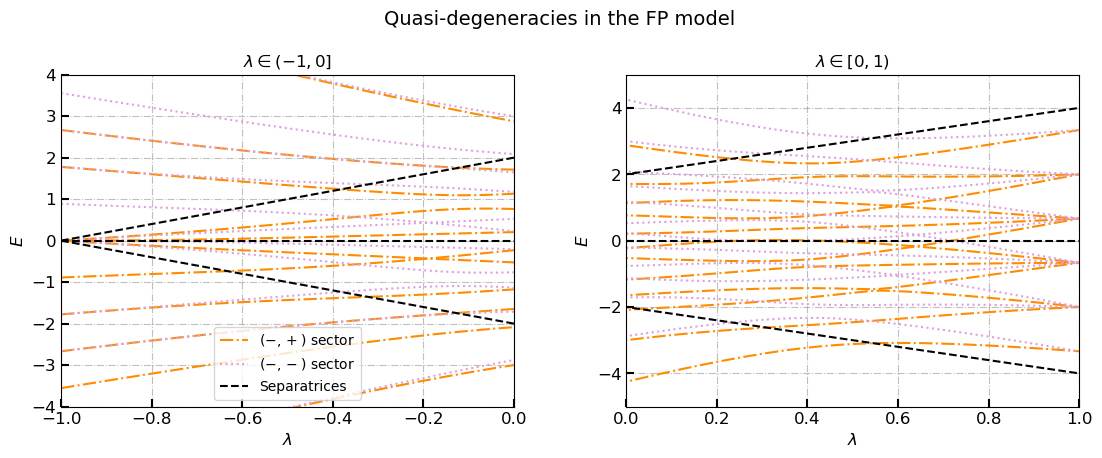

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Quasi-degeneracies in the FP model', r'$\lambda \in (-1, 0]$', r'$\lambda \in [0, 1)$'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$E$', r'$E$']
)

# for i, x in enumerate(E_spectrum_p_p.T):
#         ax1.plot(a_list, x, color = 'mediumseagreen', label = '$(+, +)$ sector' if i == 0 else "")
#         ax2.plot(a_list, x, color = 'mediumseagreen')

# for i, x in enumerate(E_spectrum_p_m.T):
#         ax1.plot(a_list, x, color = 'cornflowerblue', linestyle = '--', label = '$(+, -)$ sector' if i == 0 else "")
#         ax2.plot(a_list, x, color = 'cornflowerblue', linestyle = '--')

for i, x in enumerate(E_spectrum_m_p.T):
        ax1.plot(a_list, x, color = 'darkorange', linestyle = '-.', label = '$(-, +)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'darkorange', linestyle = '-.')

for i, x in enumerate(E_spectrum_m_m.T):
        ax1.plot(a_list, x, color = 'plum', linestyle = ':', label = '$(-, -)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'plum', linestyle = ':')

ax1.plot(a_list, 2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrices')
ax1.plot(a_list, -2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5)
ax1.plot(a_list, np.zeros(len(a_list)), color = 'black', linestyle = '--', linewidth = 1.5)
ax2.plot(a_list, 2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrices')
ax2.plot(a_list, -2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5)
ax2.plot(a_list, np.zeros(len(a_list)), color = 'black', linestyle = '--', linewidth = 1.5)

ax1.set_xlim(-1, 0)
ax1.set_ylim(-4, 4)

ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)

ax1.legend(fontsize = 10)

plt.show()

Integrability analysis of the LMG model in both regimes, first $h<J$ and then $h>J$.

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 500)
LMG_system_1.build_intensive()
r_list_all_1 = LMG_system_1.level_spacing_ratio()

LMG_system_2 = LMG(2.0, 1.0, 500)
LMG_system_2.build_intensive()
r_list_all_2 = LMG_system_2.level_spacing_ratio()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Level-spacing ratio in the LMG model', 'Full spectrum', 'Parity sectors'],
    x_labels = [r'$r_k$', r'$r_k$'],
    y_labels = ['', '']
)

ax1.hist(r_list_all_1[0], bins = 50, density = True, color = 'cornflowerblue', alpha = 0.7)
ax2.hist(r_list_all_1[1], bins = 100, density = True, color = 'lightcoral', alpha = 0.5, label = '$(+)$ sector')
ax2.hist(r_list_all_1[2], bins = 100, density = True, color = 'moccasin', alpha = 0.5, label = '$(-)$ sector')

ax2.set_xlim(0.94, 1)

ax2.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Level-spacing ratio in the LMG model', 'Full spectrum', 'Parity sectors'],
    x_labels = [r'$r_k$', r'$r_k$'],
    y_labels = ['', '']
)

ax2.tick_params(axis='x', labelrotation=30)

ax1.hist(r_list_all_2[0], bins = 50, density = True, color = 'cornflowerblue', alpha = 0.7)
ax2.hist(r_list_all_2[1], bins = 100, density = True, color = 'lightcoral', alpha = 0.5, label = '$(+)$ sector')
ax2.hist(r_list_all_2[2], bins = 100, density = True, color = 'moccasin', alpha = 0.5, label = '$(-)$ sector')

ax2.legend(fontsize = 10)

plt.show()

Integrability analysis of the FP model.

In [ ]:
a_list = np.linspace(- 1, 1, 51)
r_result = Parallel(n_jobs = - 1)(delayed(wrapper_integrability_FP)(a) for a in a_list[1 : -2])
r_result = np.array(r_result)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Transition quantum chaos-integrability in the FP model', r'$(-, +)$ sector', r'$(-, -)$ sector'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$\langle r \rangle$', r'$\langle r \rangle$'])  

ax1.plot(a_list[1 : -2], r_result[:, 0], color = 'cornflowerblue')
ax2.plot(a_list[1 : -2], r_result[:, 1], color = 'lightcoral')

ax1.axhline(y = 0.386, color = 'darkgray', linewidth = 1.5, label = 'Poisson')
ax1.axhline(y = 0.536, color = 'black', linewidth = 1.5, label = 'GOE')
ax2.axhline(y = 0.386, color = 'darkgray', linewidth = 1.5)
ax2.axhline(y = 0.536, color = 'black', linewidth = 1.5)

ax1.legend(fontsize = 10)

plt.show()

## <span style="color:orange">2.  Classical Krylov complexity</span>

<span><i>In this section, $\textcolor{red}{bla bla}$. Why is it necessary to run on Mathematica?</i></span>

In [ ]:
((3 + 1) ** 2) * ((3 + 1) ** 2)

256

In [ ]:
len([])

0

In [ ]:
h = 0.5
J = 1.0
ic_z = [[[1, 0], 1.]]
b_number = -20
LMG_classical = classicalLMG(h, J, ic_z, b_number)

In [ ]:
type(ic_z)

list

In [ ]:
LMG_classical.classical_Lanczos_algorithm()

array([0.5       , 0.4472136 , 0.69178857, 1.42273149, 1.22647262,
       1.58192564, 2.12438249, 2.16357356, 2.40588715, 2.87951003,
       3.05058144, 3.28193812, 3.58260647, 4.06721226, 3.89773884,
       4.71668705, 4.51496265, 5.20782211, 5.05830963, 5.83685803])

In [ ]:
[np.float64(0.5),
 np.float64(0.4472135954999581),
 np.float64(0.6917885721601859),
 np.float64(1.4227314890155947),
 np.float64(1.2264726172969251),
 np.float64(1.5819256376093136),
 np.float64(2.124382486660942),
 np.float64(2.1635735646396164),
 np.float64(2.4058871525172467),
 np.float64(2.879510028679714),
 np.float64(3.0505814394124506),
 np.float64(3.2819381191018646),
 np.float64(3.582606465292849),
 np.float64(4.067212261396071),
 np.float64(3.897738838936552),
 np.float64(4.716687051229836),
 np.float64(4.514962650023824),
 np.float64(5.2078221112111915),
 np.float64(5.058309629079024),
 np.float64(5.83685803208465)]

In [ ]:
type(ic_zz)

list

In [7]:
a = 0.
ic_zz = [[[1, 0, 1, 0], 1.]]
b_number = 20
FP_classical = classicalFP(a, ic_zz, b_number)

<class 'list'>


In [ ]:
FP_classical.classical_Lanczos_algorithm()

array([ 2.52982213,  3.47233968,  4.72013411,  5.66685709,  6.21286043,
        7.44283249,  7.4952765 ,  9.58306377,  9.4105079 , 11.11484156,
       11.3871763 , 12.48841138, 13.29722433, 14.09188443, 15.1276915 ,
       15.82689119, 16.80241057, 17.59512367, 18.44895755, 19.39593244])

In [ ]:
array([ 2.52982213,  3.47233968,  4.72013411,  5.66685709,  6.21286043,
        7.44283249,  7.4952765 ,  9.58306377,  9.4105079 , 11.11484156,
       11.3871763 , 12.48841138, 13.29722433, 14.09188443, 15.1276915 ,
       15.82689119, 16.80241057, 17.59512367, 18.44895755, 19.39593244])

In [ ]:
grid = np.array([1 + 1j, -1e-10j, 0.5, 1e-13, 0.5e-12 + 1j])
LanczosClassical.extract_nonzero(grid)

(array([0, 1, 2, 4]),
 array([ 1.e+00+1.e+00j, -0.e+00-1.e-10j,  5.e-01+0.e+00j,  5.e-13+1.e+00j]))

## <span style="color:orange">3.  Quantum Krylov complexity</span>

<span><i>In this section, $\textcolor{red}{bla bla}$. Why is it necessary to run on Mathematica?</i></span>

Some comments about the form of the initial operator and how it is encoded in a list for both models

The following piece of code prepares the parameters and the initial operator for executing the Lanczos algorithm on a Mathematica script. The script is ran behind the scene and the result are then stored in some variables of this notebook. The choice of <code>precsion</code> is of uttermost importance -- if it is too small, the Lanczos algorithm may terminate earlier. On the other hand, if it is too large, numerical effort may be wasted.

Let's do some warm-up.

Add coefficient for intial operator in LMG!! 

In [ ]:
np.logspace(-3, 3, 31)

array([1.00000000e-03, 1.58489319e-03, 2.51188643e-03, 3.98107171e-03,
       6.30957344e-03, 1.00000000e-02, 1.58489319e-02, 2.51188643e-02,
       3.98107171e-02, 6.30957344e-02, 1.00000000e-01, 1.58489319e-01,
       2.51188643e-01, 3.98107171e-01, 6.30957344e-01, 1.00000000e+00,
       1.58489319e+00, 2.51188643e+00, 3.98107171e+00, 6.30957344e+00,
       1.00000000e+01, 1.58489319e+01, 2.51188643e+01, 3.98107171e+01,
       6.30957344e+01, 1.00000000e+02, 1.58489319e+02, 2.51188643e+02,
       3.98107171e+02, 6.30957344e+02, 1.00000000e+03])

In [ ]:
h = 1.00000000e-03
J = 1.0

LMG_Lanczos_1 = KrylovQuantum(model = 'LMG', spin_size = 30, param = [h, J], initial_operator = [[1, 0, 1]], precision = 5500)
LMG_Lanczos_1.Lanczos_coeff_IT()

In [ ]:
LMG_Lanczos_1.Lanczos

array([1.07108719e-02, 1.94060385e-02, 1.37598032e-02, ...,
       3.32704472e-11, 2.91907583e-02, 1.49090964e-02], shape=(3624,))

In [ ]:
def wrapper(h):
    
    J = 1.0

    LMG_Lanczos = KrylovQuantum(model = 'LMG', spin_size = 30, param = [h, J], initial_operator = [[1, 0, 1]], precision = 3000)
    LMG_Lanczos.Lanczos_coeff_IT()
    result = LMG_Lanczos.LT_K_complexity()[0] / LMG_Lanczos.K_dim

    return result

In [ ]:
h_list = np.array([0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])
result_ratio_x_y = Parallel(n_jobs = - 1)(delayed(wrapper)(h) for h in h_list)

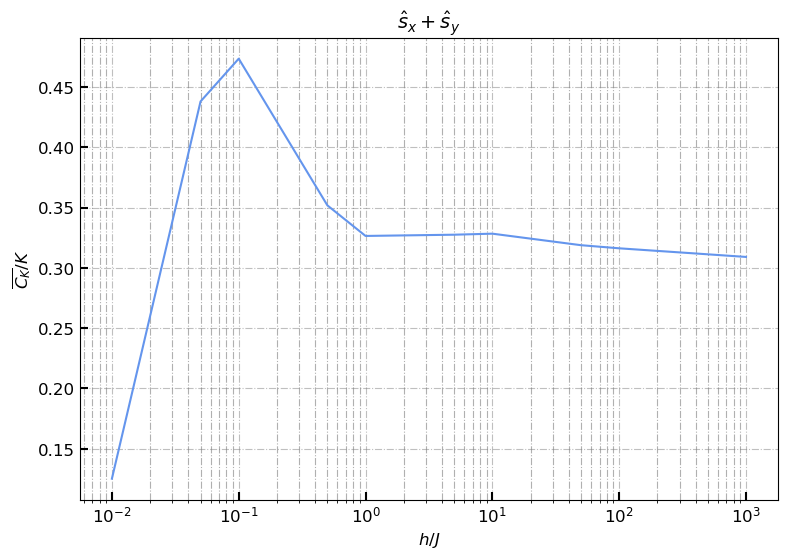

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_x+\hat{s}_y$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_x_y, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

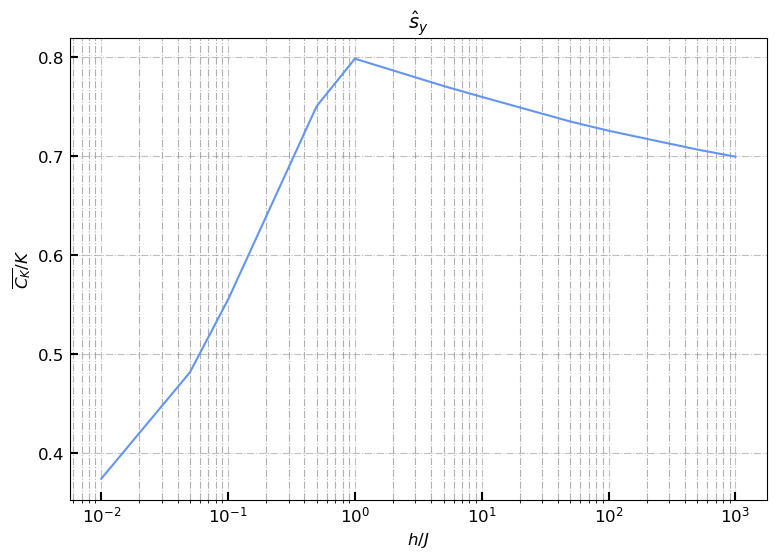

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_y$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_y, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

In [ ]:
np.logspace(-3, 3, 31)

array([1.00000000e-03, 1.58489319e-03, 2.51188643e-03, 3.98107171e-03,
       6.30957344e-03, 1.00000000e-02, 1.58489319e-02, 2.51188643e-02,
       3.98107171e-02, 6.30957344e-02, 1.00000000e-01, 1.58489319e-01,
       2.51188643e-01, 3.98107171e-01, 6.30957344e-01, 1.00000000e+00,
       1.58489319e+00, 2.51188643e+00, 3.98107171e+00, 6.30957344e+00,
       1.00000000e+01, 1.58489319e+01, 2.51188643e+01, 3.98107171e+01,
       6.30957344e+01, 1.00000000e+02, 1.58489319e+02, 2.51188643e+02,
       3.98107171e+02, 6.30957344e+02, 1.00000000e+03])

In [ ]:
np.log10(np.logspace(-3, 3, 10))

array([-3.        , -2.33333333, -1.66666667, -1.        , -0.33333333,
        0.33333333,  1.        ,  1.66666667,  2.33333333,  3.        ])

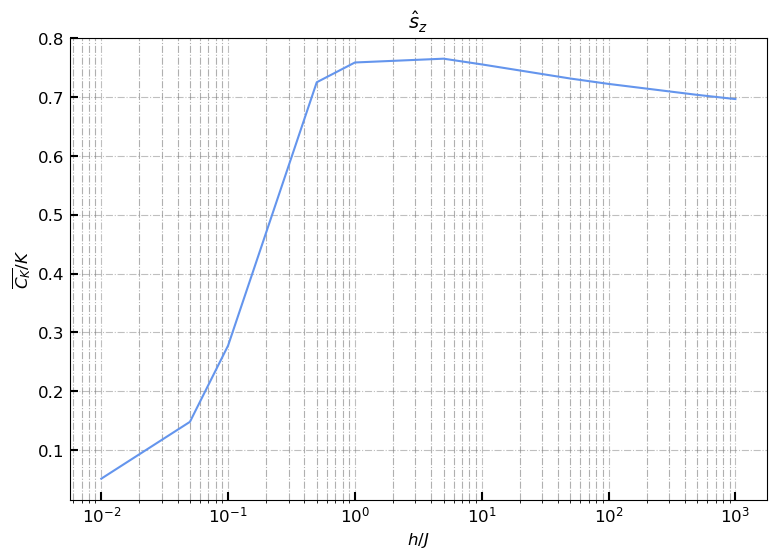

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_z$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_z, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

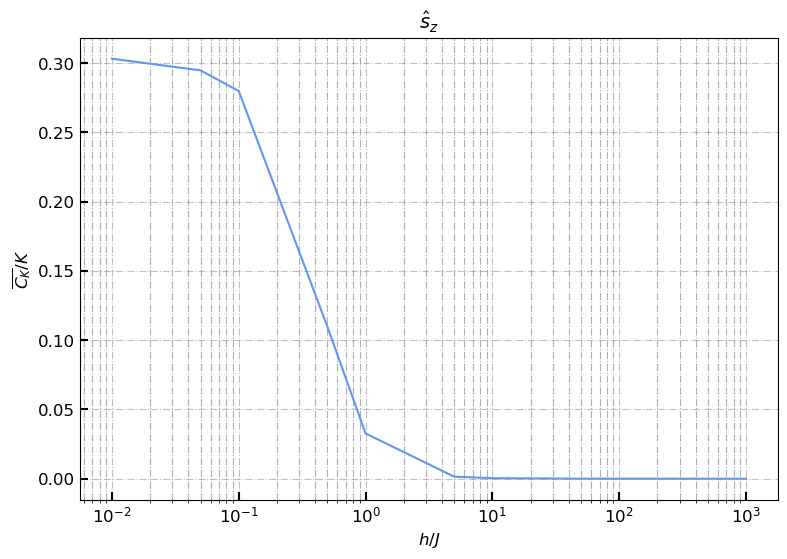

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_z$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_x, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

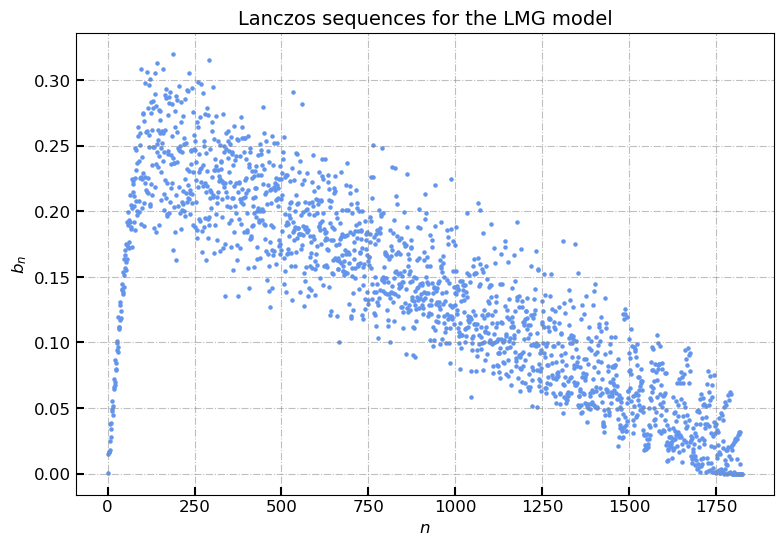

In [ ]:
fig, ax = one_plot(
    title = 'Lanczos sequences for the LMG model',
    x_label = r'$n$',
    y_label = r'$b_n$')

ax.scatter(np.arange(1, len(LMG_Lanczos_1.Lanczos) + 1), LMG_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)

plt.show()

In [ ]:
LMG_Lanczos_1.LT_K_complexity()[0] / LMG_Lanczos_1.K_dim

np.float64(0.05109472258663281)

In [ ]:
h = 0.5
J = 1.0

LMG_Lanczos_1 = KrylovQuantum(model = 'LMG', spin_size = 15, param = [h, J], initial_operator = [[0, 0, 1]], precision = 2000)
LMG_Lanczos_1.Lanczos_coeff_IT()

h = 2.0
J = 1.0

LMG_Lanczos_2 = KrylovQuantum(model = 'LMG', spin_size = 15, param = [h, J], initial_operator = [[1, 0, 1]], precision = 2000)
LMG_Lanczos_2.Lanczos_coeff_IT()  

KeyboardInterrupt: 

In [ ]:
LMG_Lanczos_1.Lanczos

array([0.03333333, 0.03074386, 0.04675125, 0.09636669, 0.08189034,
       0.10829878, 0.14222291, 0.14542671, 0.16169973, 0.19275733,
       0.20317615, 0.21835983, 0.23772429, 0.26823151, 0.25649322,
       0.30875463, 0.29413127, 0.33828452, 0.32510804, 0.37540715,
       0.35631571, 0.40040272, 0.39447574, 0.42589168, 0.42287733,
       0.45448073, 0.45131724, 0.4781051 , 0.47623081, 0.50439987,
       0.49657753, 0.52547367, 0.51862739, 0.54227036, 0.53698493,
       0.55539903, 0.55453299, 0.56343638, 0.5665942 , 0.56996497,
       0.57305804, 0.57203296, 0.57242671, 0.57039103, 0.56543045,
       0.56091676, 0.5505066 , 0.54334295, 0.52725113, 0.51734588,
       0.49478182, 0.48899687, 0.47589107, 0.51505246, 0.55781872,
       0.58077354, 0.49825334, 0.53490087, 0.55347547, 0.5552575 ,
       0.53365845, 0.54364749, 0.51774057, 0.53101608, 0.51995896,
       0.54392352, 0.51940925, 0.52247882, 0.47978098, 0.49536943,
       0.48245788, 0.52201063, 0.50193898, 0.50130697, 0.47272

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the LMG model', r'$h<J$', r'$h>J$'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(LMG_Lanczos_1.Lanczos) + 1), LMG_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(LMG_Lanczos_2.Lanczos) + 1), LMG_Lanczos_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
a = 0.0

FP_Lanczos_1 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [- 1, 0, 1, 3, 1]], precision = 1000)
FP_Lanczos_1.Lanczos_coeff_IT()

a = 0.9

FP_Lanczos_2 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [- 1, 0, 1, 3, 1]], precision = 1000)
FP_Lanczos_2.Lanczos_coeff_IT()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the FP model', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(FP_Lanczos_1.Lanczos) + 1), FP_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(FP_Lanczos_2.Lanczos) + 1), FP_Lanczos_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
h = 0.3
J = 0.707707

LMG_Lanczos_MC_1 = KrylovQuantum(model = 'LMG', spin_size = 25, param = [h, J], initial_operator = [[0, 0, 1], [1, 0, 0]], precision = 1500)
LMG_Lanczos_MC_1.Lanczos_coeff_MC(E = -0.1, E_window = 0.1, one_point = False)

h = 2.0
J = 1.0 

LMG_Lanczos_MC_2 = KrylovQuantum(model = 'LMG', spin_size = 20, param = [h, J], initial_operator = [[0, 0, 1]], precision = 500)
LMG_Lanczos_MC_2.Lanczos_coeff_MC(E = 0.5, E_window = 0.2, one_point = True)

In [ ]:
LMG_Lanczos_MC_1._K_dim

351

In [ ]:
LMG_Lanczos_MC_1.Lanczos

array([0.01731776, 0.02665934, 0.05872571, 0.0305222 , 0.07987928,
       0.05157305, 0.07715147, 0.08567573, 0.08214433, 0.09082247,
       0.11142487, 0.10019712, 0.1123304 , 0.12759508, 0.12558559,
       0.13012064, 0.14100849, 0.15509127, 0.13531206, 0.16877695,
       0.15958711, 0.16904817, 0.16067872, 0.19560734, 0.16647076,
       0.19026127, 0.17992393, 0.20958519, 0.17768705, 0.2002396 ,
       0.18795294, 0.22408209, 0.18480725, 0.19577139, 0.18893839,
       0.20953412, 0.21377487, 0.19487755, 0.20351473, 0.17425821,
       0.20889833, 0.18575903, 0.20230326, 0.19593505, 0.17503522,
       0.20793379, 0.16999854, 0.20099362, 0.18264975, 0.17530537,
       0.1852266 , 0.2031948 , 0.18825951, 0.19241941, 0.17065733,
       0.19394616, 0.1777618 , 0.19040765, 0.17394705, 0.17677632,
       0.17538442, 0.17421802, 0.17223759, 0.18335798, 0.16894707,
       0.18910508, 0.16421509, 0.20030564, 0.19365288, 0.19045895,
       0.18817612, 0.15148474, 0.19180916, 0.16408589, 0.17638

In [ ]:
LMG_Lanczos_MC_1.a_coeff

array([ 1.91841668e-05,  4.90107203e-05, -2.55856291e-04,  1.27004878e-03,
       -9.94922451e-03,  1.12265697e-02, -6.13202432e-03, -1.22523052e-02,
        2.60736418e-02, -2.92748071e-02,  3.23736340e-03,  2.13438726e-02,
       -3.81646842e-02,  1.94533200e-02,  5.16603782e-03, -2.20086633e-02,
        8.58742250e-03,  7.11245571e-03, -9.80730054e-03, -6.21912376e-03,
        1.41232522e-02, -2.25218507e-03, -6.87336746e-03,  5.93625832e-03,
        1.77212437e-02, -9.48865284e-03,  5.43008303e-03,  1.84787880e-02,
        2.86330434e-02, -2.13133500e-02,  3.63908914e-02,  2.26158223e-02,
        5.23519684e-02,  1.76637347e-03,  3.00953518e-02,  3.03921018e-02,
        8.42816280e-02,  7.30257429e-02,  4.40613098e-02,  4.00434426e-02,
        1.66242383e-02,  4.68731300e-02, -1.67127358e-03,  6.68757633e-02,
        2.15291707e-02,  6.67294473e-02,  2.83979807e-02,  2.54916215e-02,
        3.25988427e-02,  1.94577272e-02,  2.89571467e-02,  6.93521091e-02,
        6.41129546e-02,  

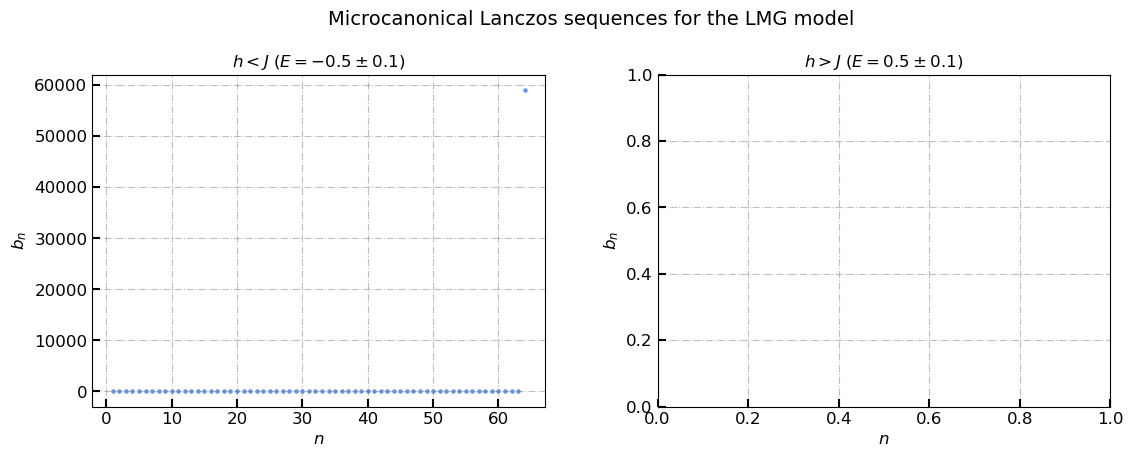

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Microcanonical Lanczos sequences for the LMG model', r'$h<J$ ($E=-0.5\pm 0.1$)', r'$h>J$ ($E=0.5\pm 0.1$)'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(LMG_Lanczos_MC_1.Lanczos) + 1), LMG_Lanczos_MC_1.Lanczos, color = 'cornflowerblue', s = 5)
#ax2.scatter(np.arange(1, len(LMG_Lanczos_MC_2.Lanczos) + 1), LMG_Lanczos_MC_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
a = 0.0

FP_Lanczos_MC_1 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [1, 0, 1, 3, 1]], precision = 1000)
a_MC_1 = FP_Lanczos_MC_1.Lanczos_coeff_MC(E = -1, E_window = 0.4, one_point = True)

a = 0.9 

FP_Lanczos_MC_2 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [1, 0, 1, 3, 1]], precision = 1000)
a_MC_2 = FP_Lanczos_MC_2.Lanczos_coeff_MC(E = 0, E_window = 0.4, one_point = True)    

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the FP model', r'$\lambda=0$ ($E=-1\pm 0.2$)', r'$\lambda=0.9$ ($E=\pm 0.2$)'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(FP_Lanczos_MC_1.Lanczos) + 1), FP_Lanczos_MC_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(FP_Lanczos_MC_2.Lanczos) + 1), FP_Lanczos_MC_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

Important: we need to terminate the Mathematica kernels manually.

In [ ]:
instances = [obj for obj in gc.get_objects() if isinstance(obj, KrylovQuantum)]

for i, obj in enumerate(instances):
    obj._session.terminate()
    print(f"[{i}] Session terminated.")

del instances
gc.collect()